In [75]:
import pandas as pd
import numpy as np

advt = pd.read_csv("Advertising.csv")
advt.drop(columns=["Unnamed: 0"], inplace=True)
advt.head(4)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5


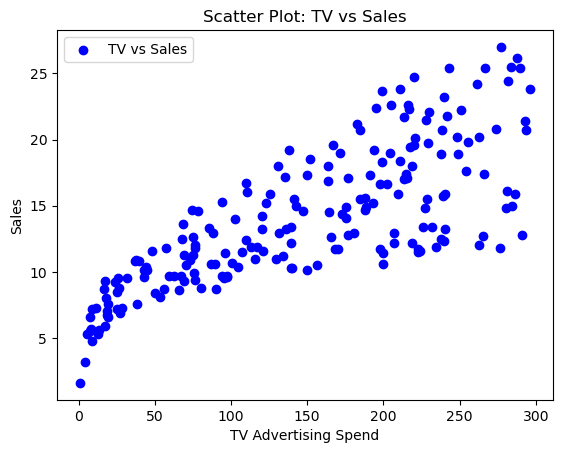

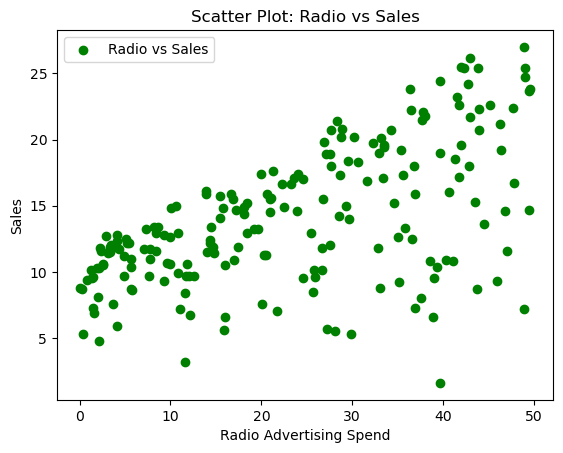

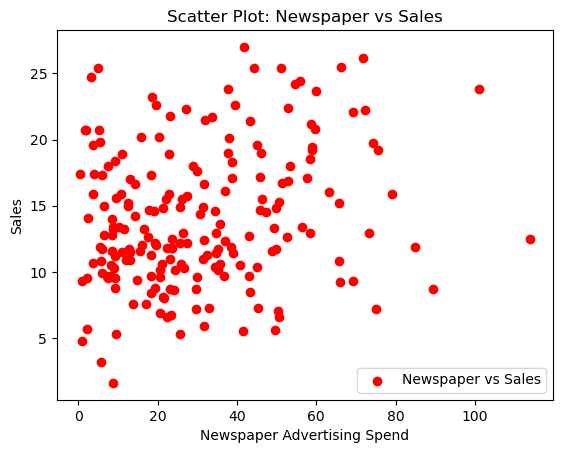

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Advertising.csv")

# Scatter plot: TV vs Sales
plt.scatter(df["TV"], df["Sales"], color="blue", label="TV vs Sales")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.title("Scatter Plot: TV vs Sales")
plt.legend()
plt.show()

# Scatter plot: Radio vs Sales
plt.scatter(df["Radio"], df["Sales"], color="green", label="Radio vs Sales")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")
plt.title("Scatter Plot: Radio vs Sales")
plt.legend()
plt.show()

# Scatter plot: Newspaper vs Sales
plt.scatter(df["Newspaper"], df["Sales"], color="red", label="Newspaper vs Sales")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")
plt.title("Scatter Plot: Newspaper vs Sales")
plt.legend()
plt.show()

In [77]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv("Advertising.csv")

# Features (independent variables)
X = df[["TV", "Radio", "Newspaper"]]

# Target (dependent variable)
y = df["Sales"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Coefficients and intercept
print("Intercept (b):", model.intercept_)
print("Coefficients (m):", model.coef_)

# Predictions
y_pred = model.predict(X_test)

# Compare actual vs predicted
results = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
print(results.head())

Intercept (b): 2.924226787250122
Coefficients (m): [ 0.04558897  0.18653389 -0.00063032]
     Actual  Predicted
50     11.4  12.589349
127     8.8   6.574663
37     14.7  15.515691
149    10.1   9.761643
19     14.6  14.085603


In [78]:
advt.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


In [79]:
advt.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [80]:
# Step 2 - EDA
#_______________________________________________________________________________

# EDA - Exploratory Data Analysis | Data Audit  | Quality check

# After importing : Immediate step is to get the friendship with the data.

# Regular available function

#advt.shape      # R : dim()          What ? Why ?
#advt.columns    # R : names()
#advt.head(2)    # R : head()
#advt.tail(2)    # R : tail()
#advt.info()     # R : str()
#advt.describe().T # R : summary()
#advt.isnull().sum()

In [81]:
# Creating Data audit Report
# Use a general function that returns multiple values |
# describe() function does not really gives me the complete end to end statistical values
import pandas as pd

# Load dataset
df = pd.read_csv("Advertising.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)

# Define function
def var_summary(advt):
    return pd.Series([
        advt.count(), 
        advt.isnull().sum(), 
        advt.sum(), 
        advt.mean(), 
        advt.median(),  
        advt.std(), 
        advt.var(), 
        advt.min(), 
        advt.quantile(0.01), 
        advt.quantile(0.05), 
        advt.quantile(0.10),
        advt.quantile(0.25), 
        advt.quantile(0.50), 
        advt.quantile(0.75), 
        advt.quantile(0.90), 
        advt.quantile(0.95), 
        advt.quantile(0.99), 
        advt.max()
    ],
    index=['N', 'NMISS', 'SUM', 'MEAN','MEDIAN', 'STD', 'VAR', 'MIN', 
           'P1' , 'P5' ,'P10' ,'P25/Q1' ,'P50/Q2' ,'P75/Q3' ,'P90' ,'P95' ,'P99' ,'MAX'])

# Apply to each column
audit_report = df.apply(var_summary)
print(audit_report.T)

               N  NMISS      SUM      MEAN  MEDIAN        STD          VAR  \
TV         200.0    0.0  29408.5  147.0425  149.75  85.854236  7370.949893   
Radio      200.0    0.0   4652.8   23.2640   22.90  14.846809   220.427743   
Newspaper  200.0    0.0   6110.8   30.5540   25.75  21.778621   474.308326   
Sales      200.0    0.0   2804.5   14.0225   12.90   5.217457    27.221853   

           MIN     P1      P5    P10  P25/Q1  P50/Q2   P75/Q3     P90  \
TV         0.7  5.387  13.195  24.88  74.375  149.75  218.825  261.44   
Radio      0.0  0.399   1.995   3.40   9.975   22.90   36.525   43.52   
Newspaper  0.3  0.999   3.600   5.99  12.750   25.75   45.100   59.07   
Sales      1.6  4.784   6.600   7.96  10.375   12.90   17.400   21.71   

               P95      P99    MAX  
TV         280.735  292.907  296.4  
Radio       46.810   49.400   49.6  
Newspaper   71.825   89.515  114.0  
Sales       23.800   25.507   27.0  


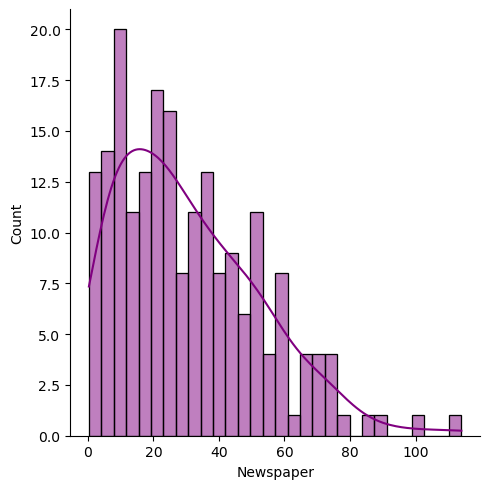

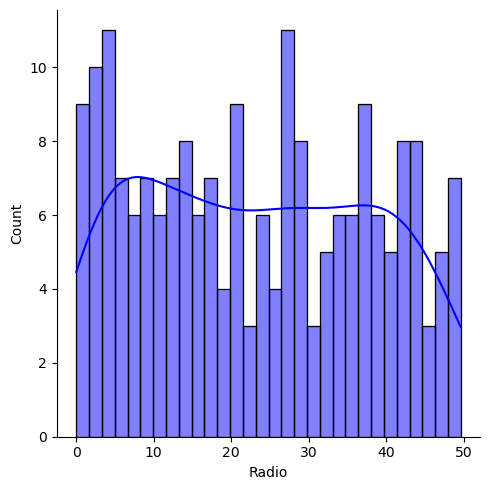

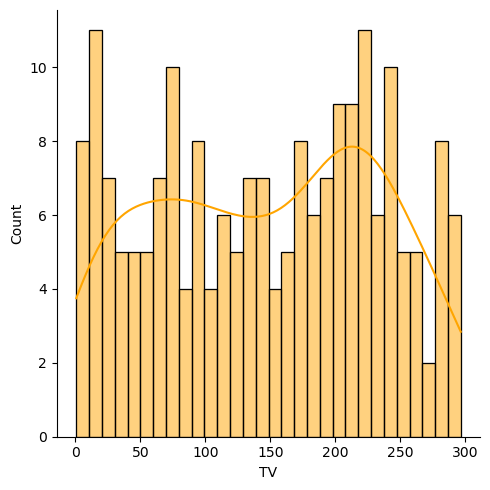

In [82]:
# Distribution of variables
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
# By creating displot to analyse that Sales seems to be normal distribution. Spending on newspaper advertisement seems to be righ skewed. 
# Most of the spends on newspaper is fairly low where as spend on radio and TV seems be uniform distribution. Spends on tv are comparatively 
# higher then spens on radio and newspaper.

sns.displot(data=advt, x="Newspaper", kde=True, bins=30, color="purple")
sns.displot(data=advt, x="Radio", kde=True, bins=30, color="blue")
sns.displot(data=advt, x="TV", kde=True, bins=30, color="orange")
plt.show()

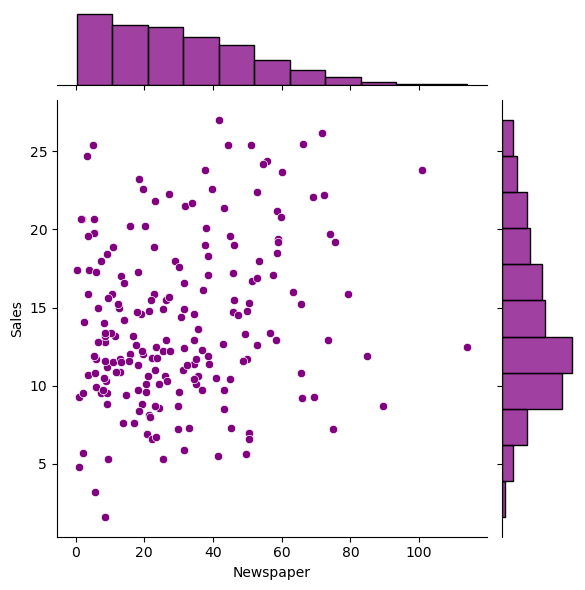

In [83]:
# Assumption No. 3  - Is there a relationship between sales[Y] and spend[X] various advertising channels?
# Sales and spend on newpaper is not highly correlaed where are sales and spend on tv is highly correlated.

import seaborn as sns
import matplotlib.pyplot as plt

# Jointplot: Newspaper vs Sales
sns.jointplot(data=advt, x="Newspaper", y="Sales", kind="scatter", color="purple")

plt.show()

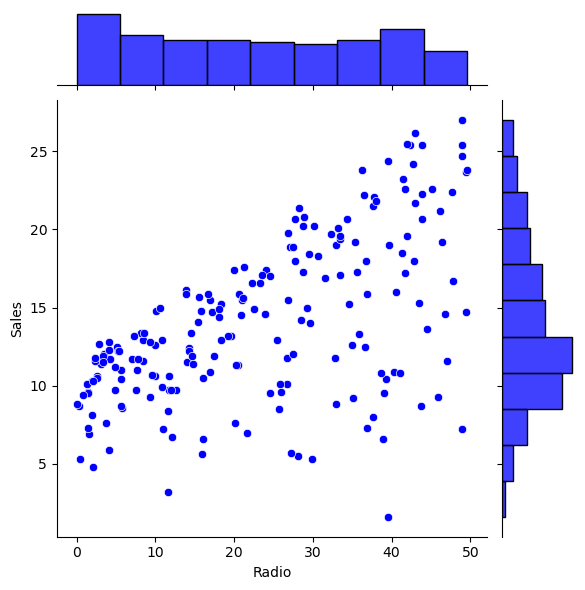

In [84]:
# Assumption No. 3  - Is there a relationship between sales[Y] and spend[X] various advertising channels?
# Sales and spend on newpaper is not highly correlaed where are sales and spend on tv is highly correlated.
import seaborn as sns
import matplotlib.pyplot as plt

# Jointplot: Newspaper vs Sales
sns.jointplot(data=advt, x="Radio", y="Sales", kind="scatter", color="blue")
plt.show()

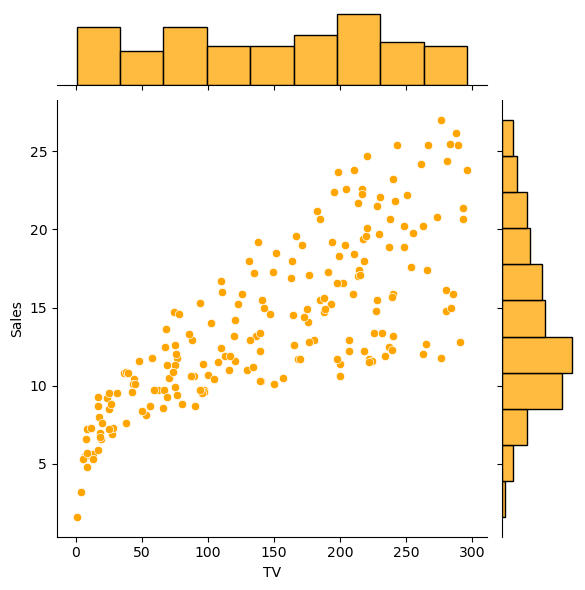

In [85]:
# Assumption No. 3  - Is there a relationship between sales[Y] and spend[X] various advertising channels?
# Sales and spend on newpaper is not highly correlaed where are sales and spend on tv is highly correlated.

import seaborn as sns
import matplotlib.pyplot as plt

# Jointplot: Newspaper vs Sales
sns.jointplot(data=advt, x="TV", y="Sales", kind="scatter", color="orange")
plt.show()

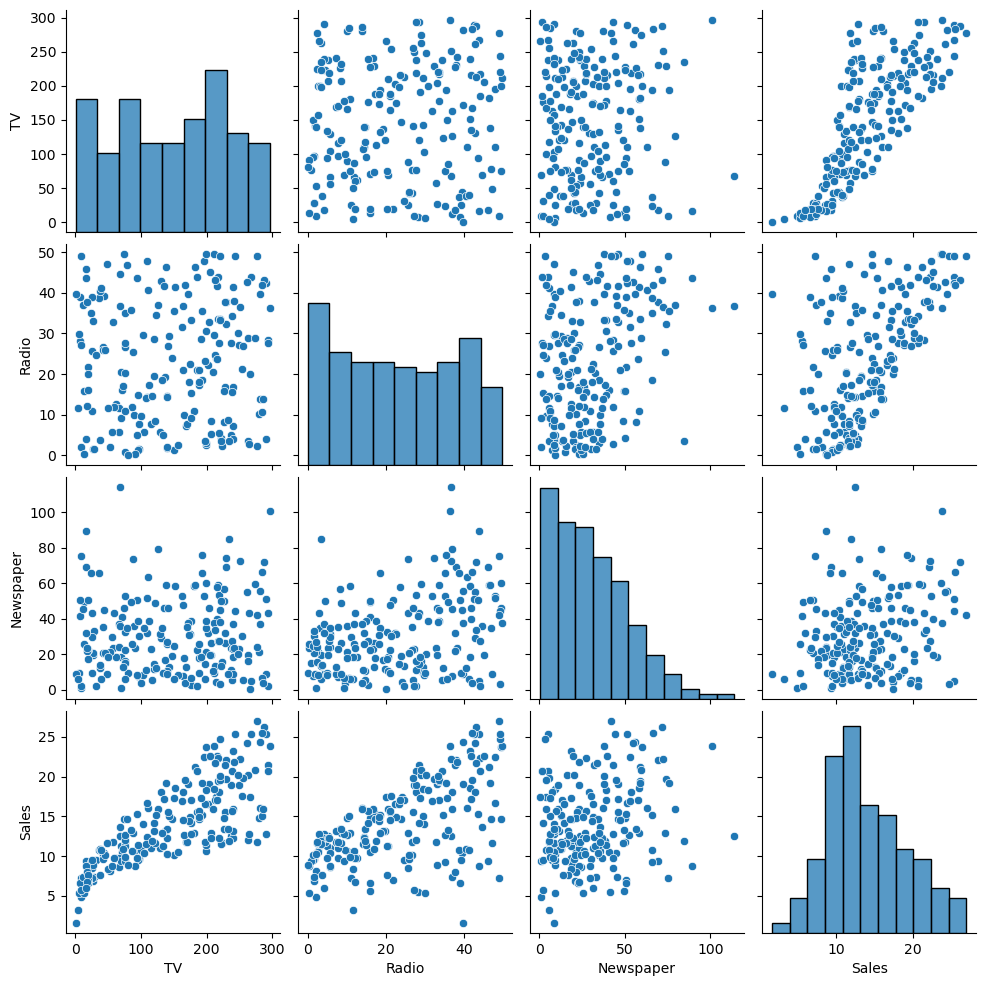

In [86]:
# Visualizing pairwise correleation
sns.pairplot(advt)

In [87]:
# Calculating correlations
(advt.TV).corr(advt.Sales) # lesser then -ve 0.5 or greater then +0.5 is supposed to have good correlation
advt.corr() # This table has to be checked for Ass# 4 : Multicollinearity

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


<Axes: >

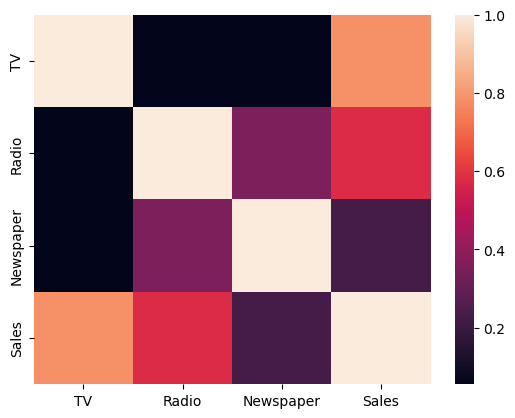

In [88]:
# Visualizing the correlations using heatmap
# The diagonal of the above matirx shows the auto-correlation of the variables. 
# It is always 1. You can observe that the correlation between TV and Sales is highest i.e. 0.78 and then between sales and radio i.e. 0.576.
# Correlations can vary from -1 to +1. Closer to +1 means strong positive correlation and close -1 means strong negative correlation. 
# Closer to 0 means not very strongly correlated.

sns.heatmap(advt.corr())

In [89]:
import statsmodels.formula.api as smf
import pandas as pd

# Things to check and interpretation in the result SUMMARY
#_______________________________________________________________________________

# 1- R2                | IDeally it should be greater .60
# 2- ADjusted R2        | IDeally it should be close and similar to R2 | [R2 > = Adj R2]
# 3- there should not be much different begtween R2 and Adj R2 | Why ? What does that means ?

# Here’s why:

# R² measures how much of the variation in Sales is explained by TV, Radio, and Newspaper.

# Adjusted R² penalizes the model for adding predictors that don’t contribute much.

# Since your dataset has 200 rows and only 3 predictors, the penalty is tiny. That’s why:

# R² ≈ 0.90

# Adjusted R² ≈ 0.90 (just slightly lower)

# 4- F STatistics - ANOVA
#   (generally used when to compare a second iterated model with the first previous one)
#(Because R2 is either gonna be same of little bit lesser iterations so ANOVA only tells me that Model has gained or not)
# F-statistic is a key measure that tests whether your overall regression model is statistically significant.
# It compares the explained variance (by predictors) to the unexplained variance (error).

# 5- to check the P value of each variable
#   to detect its significance in my model or not |

# Ho - X1 is not having impact on Sales |
         # because >> Beta1 = 0

# Ha = Beta1 # 0

# In this case, the newspaper is accepted, having P 0.86> 0.05
# P > 0.05 is insignificant

# The Durbin–Watson statistic is a diagnostic that comes with your OLS regression output. 
# It tests for autocorrelation in the residuals (whether errors are correlated across observations).
# Interpretation
    # DW ≈ 2 → No autocorrelation (ideal).
    # DW < 2 → Positive autocorrelation (errors are related across observations).
    # DW > 2 → Negative autocorrelation.

# The Jarque–Bera (JB) test is another diagnostic included in your OLS regression output. 
# It checks whether the residuals are normally distributed, which is one of the key assumptions of linear regression.
# The JB statistic is based on skewness and kurtosis of the residuals
# ************************************************************************************************************************
# Durbin Watson - number is closer to 2, hence we can conclude that there is no correlation
# JB - it's far away from 0, reject the null hypothesis. Conclusion - the residual does not follow the normal distribution

advt.columns
lm = smf.ols('Sales ~ TV + Radio + Newspaper', advt).fit() # Ordinary Least Square method: For Regression MOdel
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Tue, 26 May 2026   Prob (F-statistic):           1.58e-96
Time:                        00:16:45   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9389      0.312      9.422      0.000       2.324       3.554
TV             0.0458      0.001     32.809      0.000       0.043       0.049
Radio          0.1885      0.009     21.893      0.000       0.172       0.206
Newspaper     -0.0010      0.006     -0.177      0.860      -0.013       0.011
==============================================================================
Omnibus:                       60.414   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.241
Skew:                          -1.327   Prob(JB):                     1.44e-33
Kurtosis:                       6.332   Cond. No.                         454.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [90]:
# rerunning the model again, removing the news paper from the list

lm = smf.ols('Sales ~ TV + Radio', advt ).fit() # rerunning the model again, removing the news paper from the list
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Tue, 26 May 2026   Prob (F-statistic):           4.83e-98
Time:                        00:16:45   Log-Likelihood:                -386.20
No. Observations:                 200   AIC:                             778.4
Df Residuals:                     197   BIC:                             788.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9211      0.294      9.919      0.000       2.340       3.502
TV             0.0458      0.001     32.909      0.000       0.043       0.048
Radio          0.1880      0.008     23.382      0.000       0.172       0.204
==============================================================================
Omnibus:                       60.022   Durbin-Watson:                   2.081
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              148.679
Skew:                          -1.323   Prob(JB):                     5.19e-33
Kurtosis:                       6.292   Cond. No.                         425.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [91]:
# Getting the f value
lm.f_pvalue # this could be the P value of ANOVA (F Statistics)

np.float64(4.827361851335384e-98)

In [92]:
# Getting model parameters
lm.params

Intercept    2.921100
TV           0.045755
Radio        0.187994
dtype: float64

In [93]:
# Parameters at 95% confidence intervals

lm.conf_int()

# What you are doing with this code ?
# Why You are doing this ?

,0,1
Intercept,2.340343,3.501857
TV,0.043013,0.048497
Radio,0.172139,0.203850


In [94]:
# Verifying parameter significance
lm.pvalues

Intercept    4.565557e-19
TV           5.436980e-82
Radio        9.776972e-59
dtype: float64

In [95]:
lm.rsquared
round( float( lm.rsquared ), 2 )

0.9

In [96]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_csv("Advertising.csv")
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X = sm.add_constant(X)  # adds intercept
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Tue, 26 May 2026   Prob (F-statistic):           1.58e-96
Time:                        00:16:45   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

In [97]:
### MAKING PREDICTIONS - Applying the model
ltmpredic = lm.predict(X)

# ltmpredic - this is your Y cap [ predicted  Y]

ltmpredic[0:10]

0    20.555465
1    12.345362
2    12.337018
3    17.617116
4    13.223908
5    12.512084
6    11.718212
7    12.105516
8     3.709379
9    12.551697
dtype: float64

In [98]:
# R Square Calculation done above in OLS Summary Table
# The \(R^{2}\) (coefficient of determination) formula measures the proportion of variance in a dependent variable explained by independent variables in a regression model. 
# It is calculated as \(R^2 = 1 - \frac{SS_{res}}{SS_{tot}}\), 
# where \(SS_{res}\) is the sum of squared residuals (unexplained variance) and \(SS_{tot}\) is the total sum of squares.

residuals = y - ltmpredic
SSR = np.dot(residuals, residuals)
print("sum of squared residuals :" , SSR)

centered_y = y - y.mean()
SST = np.dot(centered_y, centered_y)
print("total sum of squares :" , SST)
R_Square = 1 - SSR/SST
print(R_Square)

sum of squared residuals : 556.9139800676182
total sum of squares : 5417.1487499999985
0.8971942610828956


In [99]:
# Adjusted R-Square calculation done above in OLS Summary table
# The Adjusted \(R^{2}\) formula is a modified version of \(R^{2}\) that accounts for the number of predictors (\(k\)) in a model, 
# punishing the addition of irrelevant variables. 
# It is calculated as:\(\text{Adjusted\ }R^{2}=1-\frac{(1-R^{2})(n-1)}{n-k-1}\)
# Where:\(R^{2}\): Sample \(R\)-squared 
# (n\): Total sample size (number of observations)
# (k\): Number of independent variables/predictors

# Degree of freedom of residual
df_resid = model.df_resid
print(df_resid)

nobs = df.shape[0]
print(nobs)

adj_R_Square = 1 - (nobs -1) / df_resid * (1 - R_Square)
print(adj_R_Square)

196.0
200
0.8956207038545725


In [100]:
# F-statistic & Prob (F-statistic) calculation as per OLS Summary table
# F-Statistic in Regression:The F-test in regression checks if the \(R^{2}\) is reliable, 
# testing the null hypothesis that all regression coefficients are zero
# If Prob (F-statistic) > 0.05 THEN THERE IS NO EVIDENCE OF RELATIONSHIP B/W independent variables (predictors) and dependent variable (Target Variable)
# If Prob (F-statistic) < 0.05 then there is atleast one varible (predictor) related to target variable

from scipy import stats

residuals = y - ltmpredic
SSR = np.dot(residuals, residuals)

centered_y = y - y.mean()
SST = np.dot(centered_y, centered_y)

ESS = SST - SSR

df_model = 3
MSE_model = ESS/df_model

df_resid = 196
MSE_resid = SSR - df_resid

f_value = MSE_model/MSE_resid

p_value = stats.f.sf(f_value, df_model, df_resid)
print(p_value)

0.004515007412803928


In [101]:
# Log-likelihood It is used to evaluate how well a model explains data; higher values suggest a better fit.
# It’s used internally to compute other statistics like AIC and BIC
# AIC (Akaike Information Criterion) and BIC (Bayesian Information Criterion) are metrics used to select the best statistical model by 
# balancing goodness of fit against model complexity (number of parameters)
# Log-likelihood
print("Log-Likelihood:", model.llf)
print("AIC:", model.aic)
print("BIC:", model.bic)

Log-Likelihood: -386.1811179443831
AIC: 780.3622358887662
BIC: 793.5555053549584


In [102]:
from sklearn import metrics
print(dir(metrics))

['ConfusionMatrixDisplay', 'DetCurveDisplay', 'DistanceMetric', 'PrecisionRecallDisplay', 'PredictionErrorDisplay', 'RocCurveDisplay', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_base', '_classification', '_dist_metrics', '_pairwise_distances_reduction', '_pairwise_fast', '_plot', '_ranking', '_regression', '_scorer', 'accuracy_score', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'auc', 'average_precision_score', 'balanced_accuracy_score', 'brier_score_loss', 'calinski_harabasz_score', 'check_scoring', 'class_likelihood_ratios', 'classification_report', 'cluster', 'cohen_kappa_score', 'completeness_score', 'confusion_matrix', 'confusion_matrix_at_thresholds', 'consensus_score', 'coverage_error', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'd2_pinball_score', 'd2_tweedie_score', 'davies_bouldin_score', 'dcg_score', 'det_curve', 'euclidean_distances', 'explained_variance_s

In [103]:
mse = metrics.mean_squared_error( advt.Sales, ltmpredic )
print(mse)
rmse = np.sqrt( mse )
print(rmse)

2.784569900338092
1.668703059366193


In [104]:
# Getting model parameters
model.params

# Parameters at 95% confidence intervals
model.conf_int()

,0,1
const,2.323762,3.554016
TV,0.043014,0.048516
Radio,0.171547,0.205513
Newspaper,-0.012616,0.010541


In [105]:
# Verifying parameter significance
model.pvalues

const        1.267295e-17
TV           1.509960e-81
Radio        1.505339e-54
Newspaper    8.599151e-01
dtype: float64

In [106]:
model.rsquared
round( float( model.rsquared ), 2 )

0.9

In [107]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  advt[["TV", "Radio", "Newspaper"]],
  advt.Sales,
  test_size=0.3,
  random_state = 42 )

In [108]:
print(len(X_train))
print(len( X_test))

140
60


In [109]:
## Building the model with train set and make predictions on test set
linreg = LinearRegression()
linreg.fit( X_train, y_train )
y_pred = linreg.predict( X_test )

In [110]:
print("Slope (m):", linreg.coef_)
print("Intercept (b):", linreg.intercept_)

Slope (m): [0.04405928 0.1992875  0.00688245]
Intercept (b): 2.7089490925159083


In [111]:
from sklearn import metrics
rmse = np.sqrt( metrics.mean_squared_error( y_test, y_pred ) )
print(rmse)
y_pred_t = linreg.predict(X_train)
rmse_t = np.sqrt( metrics.mean_squared_error( y_train, y_pred_t) )
print(rmse_t)

1.9485372043446376
1.574596830590544


In [112]:
metrics.r2_score( y_train, y_pred_t )

0.9055159502227753

In [113]:
metrics.r2_score( y_test, y_pred )

0.8609466508230369

In [114]:
list( zip( ["TV", "Radio", "Newspaper"], list( linreg.coef_ ) ) )

[('TV', np.float64(0.04405928095746522)),
 ('Radio', np.float64(0.19928749689893943)),
 ('Newspaper', np.float64(0.006882452222275445))]

Intercept (β0): 3.126553806941841
Coefficients (β1, β2): [0.0474347  0.17565547]
        TV  Radio  Actual Sales  Predicted Sales
112  175.7   15.4          14.1        14.165926
29    70.6   16.0          10.5         9.285931
182   56.2    5.7           8.7         6.793620
199  232.1    8.6          13.4        15.646786
193  166.8   42.0          19.6        18.416192
MSE: 4.403851961845133
RMSE: 2.098535670853639
R²: 0.7629335290913724


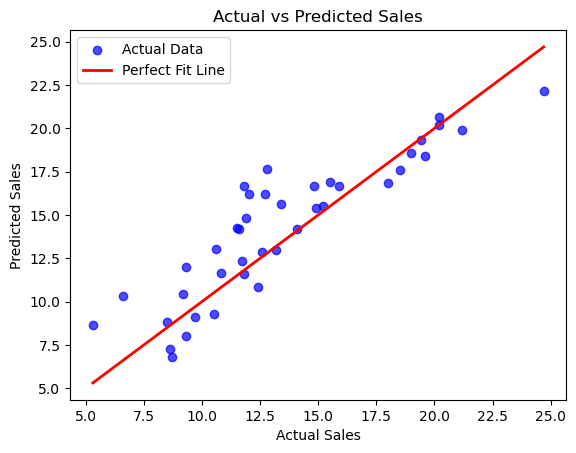

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("Advertising.csv")

# Features and target
X = df[["TV", "Radio"]]   # predictors
y = df["Sales"]                        # target

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Print coefficients and intercept
print("Intercept (β0):", model.intercept_)
print("Coefficients (β1, β2):", model.coef_)

# Predict on test set
y_pred = model.predict(X_test)

# Show first few predictions vs actual
results = pd.DataFrame({
    "TV": X_test["TV"],
    "Radio": X_test["Radio"],
    "Actual Sales": y_test,
    "Predicted Sales": y_pred
})
print(results.head())

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

# Scatter plot: Actual vs Predicted
plt.scatter(y_test, y_pred, color="blue", label="Actual Data", alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=2, label="Perfect Fit Line")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()

In [116]:
import matplotlib
print(matplotlib.__version__)

3.10.8
